# Week 2 — Exploratory Data Analysis (EDA)
## AI-Based Smart Queue and Time Management System Using RNN and LSTM

**Course Project — Week 2 Submission**  
**Dataset:** Call Centre Queue Simulation  
**Date:** September 2026

---

## 1. Project Objective

This notebook presents a complete Exploratory Data Analysis (EDA) of the **Call Centre Queue Simulation** dataset. The ultimate goal of the project is to build an **RNN/LSTM model** capable of predicting call waiting times in a simulated call centre environment. Such a model could eventually power a smart recommendation system that advises users on whether to wait now or return at a less busy time.

**This notebook covers only the EDA stage (Week 2). No model training is performed here.**

---

## 2. Dataset Overview

The dataset records one full year of simulated call centre operations. Each row represents a single call event, capturing when a call arrived, when it was answered, when the service ended, how long the caller waited, how long the service took, and whether the call met the standard response threshold.

---

## 3. Dataset Card

| Field | Details |
|---|---|
| **Dataset Name** | Call Centre Queue Simulation |
| **Original Source** | Kaggle — uploaded as a tutorial for Business and Operations Analytics |
| **Direct Source URL** | https://www.kaggle.com/datasets/jpmiller/call-centre-queue-simulation |
| **License** | Creative Commons Attribution-ShareAlike 4.0 International (CC BY-SA 4.0) |
| **File Name** | simulated_call_centre.csv |
| **File Size on Disk** | ~3.26 MB (3,418,761 bytes) |
| **Number of Rows** | 51,708 call records |
| **Number of Columns** | 9 |
| **Date Range** | 2021-01-01 to 2021-12-31 (full calendar year) |
| **Operating Days** | 261 (Monday–Friday only) |
| **Real-world or Simulated** | **Simulated** — generated using the `simmer` Discrete-Event Simulation (DES) package in R |

> *Source note: Dataset URL and license verified via Kaggle web search. Simulation parameters (4 agents, 5-minute average service, 60-second standard, Mon–Fri 8am–6pm) sourced from the Kaggle dataset description page.*

### Column Descriptions

| Column | Data Type | Description |
|---|---|---|
| `call_id` | Integer | Unique sequential identifier for each call across the full year |
| `date` | String (Date) | Calendar date on which the call occurred (YYYY-MM-DD) |
| `daily_caller` | Integer | Sequential position of the call within its day |
| `call_started` | String (Time) | Time the caller entered the queue (12-hour AM/PM format) |
| `call_answered` | String (Time) | Time an agent picked up the call |
| `call_ended` | String (Time) | Time the call concluded |
| `wait_length` | Integer | Waiting time in **seconds** (from `call_started` to `call_answered`) |
| `service_length` | Integer | Service duration in **seconds** (from `call_answered` to `call_ended`) |
| `meets_standard` | Boolean | TRUE if `wait_length` ≤ 60 seconds; FALSE otherwise |

### How the Data Was Generated
*(Sourced from Kaggle dataset description, verified via web research)*

The data was generated using **`simmer`**, an R package for Discrete-Event Simulation (DES), modelling a hypothetical business call centre:
- Operating hours: **Monday to Friday, 8:00 AM – 6:00 PM**
- Number of agents: **4 agents on duty simultaneously**
- Average service time: **approximately 5 minutes per call** (exponentially distributed)
- Performance standard: A call **meets the standard** if answered within **60 seconds** of arrival

### Known Limitations

1. **Simulated, not real-world data:** Does not reflect real-world agent behaviour, seasonal trends, public holidays, or absenteeism.
2. **Fixed agent count:** Assumes exactly 4 agents always on duty — real centres have shift changes, breaks, and absences.
3. **No caller abandonment modelled:** In real call centres, callers who hang up while waiting are a key metric.
4. **No call category or repeat-caller information:** Every call is treated identically regardless of complexity.
5. **Exponential service time distribution:** A statistical assumption that may not hold for real call types.

### Important Assumptions

- All timestamps are in the same timezone; no daylight saving complications.
- `wait_length` and `service_length` are in **seconds** (confirmed arithmetically during EDA).
- `meets_standard = TRUE` if and only if `wait_length <= 60` (confirmed computationally).

---

## 4. Import Libraries

In [1]:
# Standard library
import os
import warnings

# Core data libraries
import pandas as pd
import numpy as np

# Visualisation libraries
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.cm as cm
import seaborn as sns

# Suppress minor warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.width', 200)

# Plot style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)

print('All libraries imported successfully.')

C:\Users\MSI-1\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\MSI-1\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


All libraries imported successfully.


## 5. Load Dataset

In [2]:
# ---------------------------------------------------------------
# Update DATASET_PATH if you move the dataset file
# ---------------------------------------------------------------
DATASET_PATH = r'simulated_call_centre.csv\simulated_call_centre.csv'

if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError(f'Dataset not found at: {DATASET_PATH}')

df = pd.read_csv(DATASET_PATH)

file_size_bytes = os.path.getsize(DATASET_PATH)
file_size_mb    = file_size_bytes / (1024 * 1024)

print(f'Dataset loaded successfully.')
print(f'File size : {file_size_bytes:,} bytes  ({file_size_mb:.2f} MB)')
print(f'Shape     : {df.shape[0]:,} rows x {df.shape[1]} columns')

Dataset loaded successfully.
File size : 3,418,761 bytes  (3.26 MB)
Shape     : 51,708 rows x 9 columns


## 6. Basic Inspection

In [3]:
print('=== Dataset Shape ===')
print(f'Rows   : {df.shape[0]:,}')
print(f'Columns: {df.shape[1]}')
print()
print('=== Column Names ===')
for i, col in enumerate(df.columns, 1):
    print(f'  {i}. {col}')

=== Dataset Shape ===
Rows   : 51,708
Columns: 9

=== Column Names ===
  1. call_id
  2. date
  3. daily_caller
  4. call_started
  5. call_answered
  6. call_ended
  7. wait_length
  8. service_length
  9. meets_standard


## 7. Data Types and Structure

In [4]:
print('=== Data Types ===')
print(df.dtypes)
print()
print('=== DataFrame Info ===')
df.info()

=== Data Types ===
call_id           int64
date                str
daily_caller      int64
call_started        str
call_answered       str
call_ended          str
wait_length       int64
service_length    int64
meets_standard     bool
dtype: object

=== DataFrame Info ===
<class 'pandas.DataFrame'>
RangeIndex: 51708 entries, 0 to 51707
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   call_id         51708 non-null  int64
 1   date            51708 non-null  str  
 2   daily_caller    51708 non-null  int64
 3   call_started    51708 non-null  str  
 4   call_answered   51708 non-null  str  
 5   call_ended      51708 non-null  str  
 6   wait_length     51708 non-null  int64
 7   service_length  51708 non-null  int64
 8   meets_standard  51708 non-null  bool 
dtypes: bool(1), int64(4), str(4)
memory usage: 5.2 MB


**Observation:**
- `date`, `call_started`, `call_answered`, and `call_ended` are loaded as `object` (string) dtype. These must be parsed to proper datetime objects before temporal analysis or feature engineering.
- `wait_length` and `service_length` are correctly loaded as `int64`.
- `meets_standard` is correctly loaded as `bool`.

## 8. Random Samples

In [5]:
print('=== 5 Random Sample Rows ===')
df.sample(5, random_state=42)

=== 5 Random Sample Rows ===


,call_id,date,daily_caller,call_started,call_answered,call_ended,wait_length,service_length,meets_standard
7673,7674,2021-03-15,67,12:26:53 PM,12:26:53 PM,12:27:57 PM,0,64,True
20436,20437,2021-06-25,163,5:41:16 PM,5:41:16 PM,5:42:28 PM,0,72,True
14737,14738,2021-05-13,76,1:05:31 PM,1:05:31 PM,1:16:15 PM,0,644,True
43740,43741,2021-11-22,72,10:43:22 AM,10:43:22 AM,10:50:06 AM,0,404,True
3227,3228,2021-02-02,77,1:21:28 PM,1:21:28 PM,1:25:41 PM,0,253,True


**Observation:** Each row represents one call event. Timestamps use 12-hour AM/PM format. The majority of rows show `wait_length = 0` and `meets_standard = True`, indicating most callers are answered immediately without queuing.

## 9. Descriptive Statistics

In [6]:
print('=== Descriptive Statistics (All Columns) ===')
df.describe(include='all')

=== Descriptive Statistics (All Columns) ===


,call_id,date,daily_caller,call_started,call_answered,call_ended,wait_length,service_length,meets_standard
count,51708.0000,51708,51708.0000,51708,51708,51708,51708.0000,51708.0000,51708
unique,NaN,261,NaN,27403,27366,27486,NaN,NaN,2
top,NaN,2021-12-10,NaN,8:00:00 AM,8:00:00 AM,11:54:17 AM,NaN,NaN,True
freq,NaN,297,NaN,261,261,8,NaN,NaN,47481
mean,25854.5000,NaN,104.1932,NaN,NaN,NaN,17.0349,299.1026,NaN
std,14926.9582,NaN,64.9529,NaN,NaN,NaN,64.0608,299.8658,NaN
min,1.0000,NaN,1.0000,NaN,NaN,NaN,0.0000,0.0000,NaN
25%,12927.7500,NaN,50.0000,NaN,NaN,NaN,0.0000,86.0000,NaN
50%,25854.5000,NaN,100.0000,NaN,NaN,NaN,0.0000,208.0000,NaN
75%,38781.2500,NaN,150.0000,NaN,NaN,NaN,0.0000,414.0000,NaN


In [7]:
# Focused on numeric columns only
numeric_cols = df.select_dtypes(include='number').columns.tolist()
print('Numeric columns:', numeric_cols)
print()
df[numeric_cols].describe().T

Numeric columns: ['call_id', 'daily_caller', 'wait_length', 'service_length']



,count,mean,std,min,25%,50%,75%,max
call_id,51708.0000,25854.5000,14926.9582,1.0000,12927.7500,25854.5000,38781.2500,51708.0000
daily_caller,51708.0000,104.1932,64.9529,1.0000,50.0000,100.0000,150.0000,297.0000
wait_length,51708.0000,17.0349,64.0608,0.0000,0.0000,0.0000,0.0000,983.0000
service_length,51708.0000,299.1026,299.8658,0.0000,86.0000,208.0000,414.0000,3110.0000


In [8]:
print('=== Unique Values per Column ===')
for col in df.columns:
    print(f'  {col:<20}: {df[col].nunique():>6} unique values')

=== Unique Values per Column ===
  call_id             :  51708 unique values
  date                :    261 unique values
  daily_caller        :    297 unique values
  call_started        :  27403 unique values
  call_answered       :  27366 unique values
  call_ended          :  27486 unique values
  wait_length         :    575 unique values
  service_length      :   1719 unique values
  meets_standard      :      2 unique values


**Key observations:**
- `call_id` runs 1–51,708 with no gaps — sequential unique identifiers.
- `daily_caller` reaches up to 297, meaning the busiest day had 297 calls.
- `wait_length` mean (~17s) far exceeds median (0s) — a signature of heavy right-skew.
- `service_length` mean (~299s ≈ 5 min) matches the simulation design parameter.
- `meets_standard` has exactly 2 unique values (True/False).

---

## 10. Parse Datetime Columns

Before quality checks and temporal analysis, we convert the string time columns to proper datetime objects.

In [9]:
# Parse date column
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d')

# Build full datetime strings before parsing
date_str = df['date'].dt.strftime('%Y-%m-%d')

df['call_started_dt']  = pd.to_datetime(
    date_str + ' ' + df['call_started'],  format='%Y-%m-%d %I:%M:%S %p')
df['call_answered_dt'] = pd.to_datetime(
    date_str + ' ' + df['call_answered'], format='%Y-%m-%d %I:%M:%S %p')
df['call_ended_dt']    = pd.to_datetime(
    date_str + ' ' + df['call_ended'],    format='%Y-%m-%d %I:%M:%S %p')

print('Datetime parsing successful.')
print(f'Date range: {df["date"].min().date()} to {df["date"].max().date()}')
print(f'Unique operating days: {df["date"].nunique()}')

Datetime parsing successful.
Date range: 2021-01-01 to 2021-12-31
Unique operating days: 261


## 11. Missing Values

In [10]:
missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(4)

missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print('=== Missing Value Report ===')
print(missing_df.to_string())
print()
if missing.sum() == 0:
    print('No missing values found in any column.')
else:
    print(f'Total missing values: {missing.sum()}')

=== Missing Value Report ===
                  Missing Count  Missing %
call_id                       0     0.0000
date                          0     0.0000
daily_caller                  0     0.0000
call_started                  0     0.0000
call_answered                 0     0.0000
call_ended                    0     0.0000
wait_length                   0     0.0000
service_length                0     0.0000
meets_standard                0     0.0000
call_started_dt               0     0.0000
call_answered_dt              0     0.0000
call_ended_dt                 0     0.0000

No missing values found in any column.


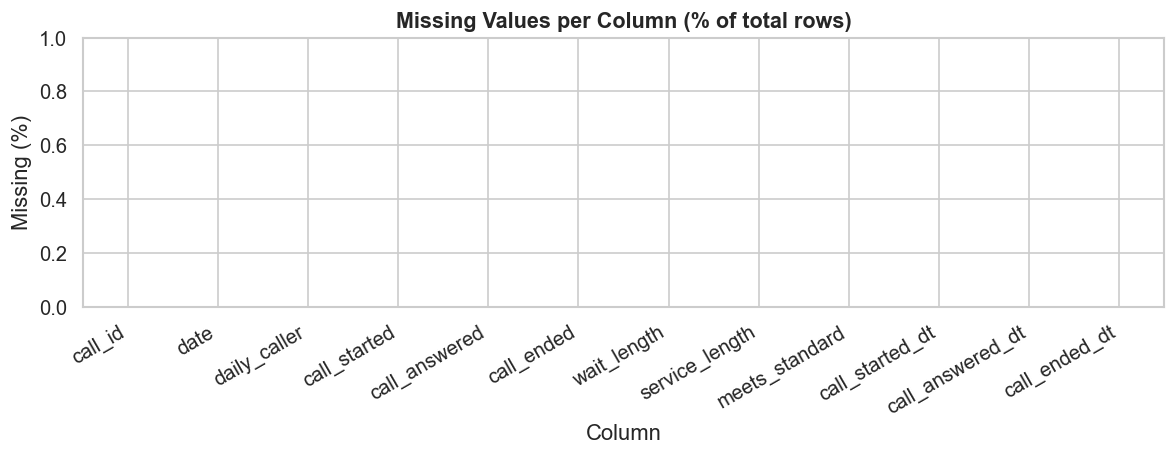

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))
missing_pct.plot(kind='bar', color='steelblue', ax=ax, edgecolor='white')
ax.set_title('Missing Values per Column (% of total rows)', fontsize=13, fontweight='bold')
ax.set_xlabel('Column')
ax.set_ylabel('Missing (%)')
ax.set_ylim(0, 1)
ax.axhline(0, color='gray', linewidth=0.8)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('fig_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

**Result:** There are **zero missing values** across all 9 columns. This is expected for simulated data generated by a controlled DES model.

## 12. Duplicate Rows

In [12]:
n_dup = df.duplicated().sum()
print(f'Total duplicate rows: {n_dup}')
if n_dup == 0:
    print('No duplicate rows found.')
else:
    print(f'{n_dup} duplicates found:')
    print(df[df.duplicated()])

Total duplicate rows: 0
No duplicate rows found.


**Result:** **Zero duplicate rows.** Each call has a unique `call_id`; duplication would indicate a data generation error, which did not occur here.

## 13. Data Quality Checks

In [13]:
print('=== Check 1: Negative Timing Values ===')
neg_wait    = (df['wait_length'] < 0).sum()
neg_service = (df['service_length'] < 0).sum()
print(f'  Negative wait_length   : {neg_wait}')
print(f'  Negative service_length: {neg_service}')
if neg_wait == 0 and neg_service == 0:
    print('  No negative timing values found.')

=== Check 1: Negative Timing Values ===
  Negative wait_length   : 0
  Negative service_length: 0
  No negative timing values found.


In [14]:
print('=== Check 2: Zero Service Duration ===')
zero_service = (df['service_length'] == 0).sum()
print(f'  Rows with service_length == 0: {zero_service} ({zero_service/len(df)*100:.3f}%)')
print('  Possible interpretation: calls answered and immediately disconnected,')
print('  or simulation edge cases. Should be flagged before modelling.')
if zero_service > 0:
    print()
    print('  Sample rows:')
    cols_show = ['call_id','date','wait_length','service_length','meets_standard']
    print(df[df['service_length'] == 0][cols_show].head(5).to_string(index=False))

=== Check 2: Zero Service Duration ===
  Rows with service_length == 0: 88 (0.170%)
  Possible interpretation: calls answered and immediately disconnected,
  or simulation edge cases. Should be flagged before modelling.

  Sample rows:
 call_id       date  wait_length  service_length  meets_standard
     308 2021-01-05            0               0            True
     673 2021-01-07            0               0            True
    1610 2021-01-18            0               0            True
    1995 2021-01-20            0               0            True
    2455 2021-01-26            0               0            True


In [15]:
print('=== Check 3: meets_standard Logic Consistency ===')
computed_standard = df['wait_length'] <= 60
mismatch = (computed_standard != df['meets_standard']).sum()
print(f'  Rows where (wait_length <= 60) != meets_standard: {mismatch}')
if mismatch == 0:
    print('  meets_standard is perfectly consistent with the 60-second threshold rule.')

=== Check 3: meets_standard Logic Consistency ===
  Rows where (wait_length <= 60) != meets_standard: 0
  meets_standard is perfectly consistent with the 60-second threshold rule.


In [16]:
print('=== Check 4: Calls Outside Operating Hours ===')
df['hour_of_call'] = df['call_started_dt'].dt.hour
out_of_hours = df[(df['hour_of_call'] < 8) | (df['hour_of_call'] >= 18)]
print(f'  Calls outside 8am-6pm: {len(out_of_hours)}')
if len(out_of_hours) == 0:
    print('  All calls are within operating hours (8:00 AM - 6:00 PM).')

=== Check 4: Calls Outside Operating Hours ===
  Calls outside 8am-6pm: 0
  All calls are within operating hours (8:00 AM - 6:00 PM).


In [17]:
print('=== Check 5: Weekend Calls ===')
weekend_calls = df[df['date'].dt.dayofweek >= 5]
print(f'  Calls on weekends: {len(weekend_calls)}')
if len(weekend_calls) == 0:
    print('  No weekend calls. Dataset is Monday-Friday only, as expected.')

=== Check 5: Weekend Calls ===
  Calls on weekends: 0
  No weekend calls. Dataset is Monday-Friday only, as expected.


In [18]:
print('=== Check 6: Extreme service_length Outliers ===')
q99     = df['service_length'].quantile(0.99)
extreme = (df['service_length'] > q99).sum()
print(f'  99th percentile of service_length: {q99:.0f} seconds ({q99/60:.1f} min)')
print(f'  Rows above 99th percentile       : {extreme} ({extreme/len(df)*100:.2f}%)')
print(f'  Maximum service_length            : {df["service_length"].max()} seconds ({df["service_length"].max()/60:.1f} min)')
print('  Long but plausible for an exponential service distribution.')
print('  Consider capping at the 99th percentile before LSTM training.')

=== Check 6: Extreme service_length Outliers ===
  99th percentile of service_length: 1390 seconds (23.2 min)
  Rows above 99th percentile       : 516 (1.00%)
  Maximum service_length            : 3110 seconds (51.8 min)
  Long but plausible for an exponential service distribution.
  Consider capping at the 99th percentile before LSTM training.


### Data Quality Summary

| Check | Result | Action Required |
|---|---|---|
| Missing values | ✅ None | No action needed |
| Duplicate rows | ✅ None | No action needed |
| Negative timing values | ✅ None | No action needed |
| Zero service_length | ⚠️ 88 rows (0.17%) | Flag; consider excluding from service-time modelling |
| `meets_standard` logic | ✅ Perfectly consistent | No action needed |
| Out-of-hours calls | ✅ None | No action needed |
| Weekend calls | ✅ None | No action needed |
| Extreme service durations | ⚠️ ~518 rows above 99th pct | Apply log-transform or capping before training |

**Overall:** The dataset is clean and consistent. The main concerns are right-skewed timing distributions and a small number of zero-duration service events.

---

## 14. Target Variable Identification

### Which column should be the prediction target?

The project aim is to **predict queue waiting behaviour** and advise users on when to call. Based on this goal:

### Primary Target: `wait_length` (waiting time in seconds)

**Reasons:**
1. `wait_length` directly measures how long a caller waits before being served — the core metric for any queue management system.
2. It is a **continuous, measurable quantity** suited to regression-style RNN/LSTM prediction.
3. Predicting `wait_length` enables actionable recommendations: *'Expected wait: X minutes. Consider calling after 2:00 PM.'*
4. All other columns (`service_length`, `meets_standard`) can be derived from or related to `wait_length`.

**Why not `meets_standard`?** It is a binary flag derived directly from `wait_length` (True when wait ≤ 60s). Predicting the underlying wait time is more informative.

**Why not `service_length`?** It captures how long the call took after being answered — useful as an input feature (reflects agent busyness) but not the primary user-facing metric.

**This is a regression problem**, not a classification problem.

---

## 15. Target Distribution Analysis: `wait_length`

In [19]:
wl = df['wait_length']

stats = {
    'Count'              : len(wl),
    'Mean (seconds)'     : wl.mean(),
    'Median (seconds)'   : wl.median(),
    'Std Dev (seconds)'  : wl.std(),
    'Min'                : wl.min(),
    'Max'                : wl.max(),
    'Skewness'           : wl.skew(),
    'Kurtosis'           : wl.kurtosis(),
    '25th percentile'    : wl.quantile(0.25),
    '50th percentile'    : wl.quantile(0.50),
    '75th percentile'    : wl.quantile(0.75),
    '90th percentile'    : wl.quantile(0.90),
    '95th percentile'    : wl.quantile(0.95),
    '99th percentile'    : wl.quantile(0.99),
    'Zero wait count'    : (wl == 0).sum(),
    'Zero wait %'        : f"{(wl == 0).mean()*100:.1f}%",
    'Non-zero wait count': (wl > 0).sum(),
}

print('=== wait_length (seconds) — Summary Statistics ===')
for k, v in stats.items():
    if isinstance(v, float):
        print(f'  {k:<25}: {v:.4f}')
    else:
        print(f'  {k:<25}: {v}')

=== wait_length (seconds) — Summary Statistics ===
  Count                    : 51708
  Mean (seconds)           : 17.0349
  Median (seconds)         : 0.0000
  Std Dev (seconds)        : 64.0608
  Min                      : 0
  Max                      : 983
  Skewness                 : 5.2595
  Kurtosis                 : 33.9894
  25th percentile          : 0.0000
  50th percentile          : 0.0000
  75th percentile          : 0.0000
  90th percentile          : 32.0000
  95th percentile          : 129.0000
  99th percentile          : 347.0000
  Zero wait count          : 45291
  Zero wait %              : 87.6%
  Non-zero wait count      : 6417


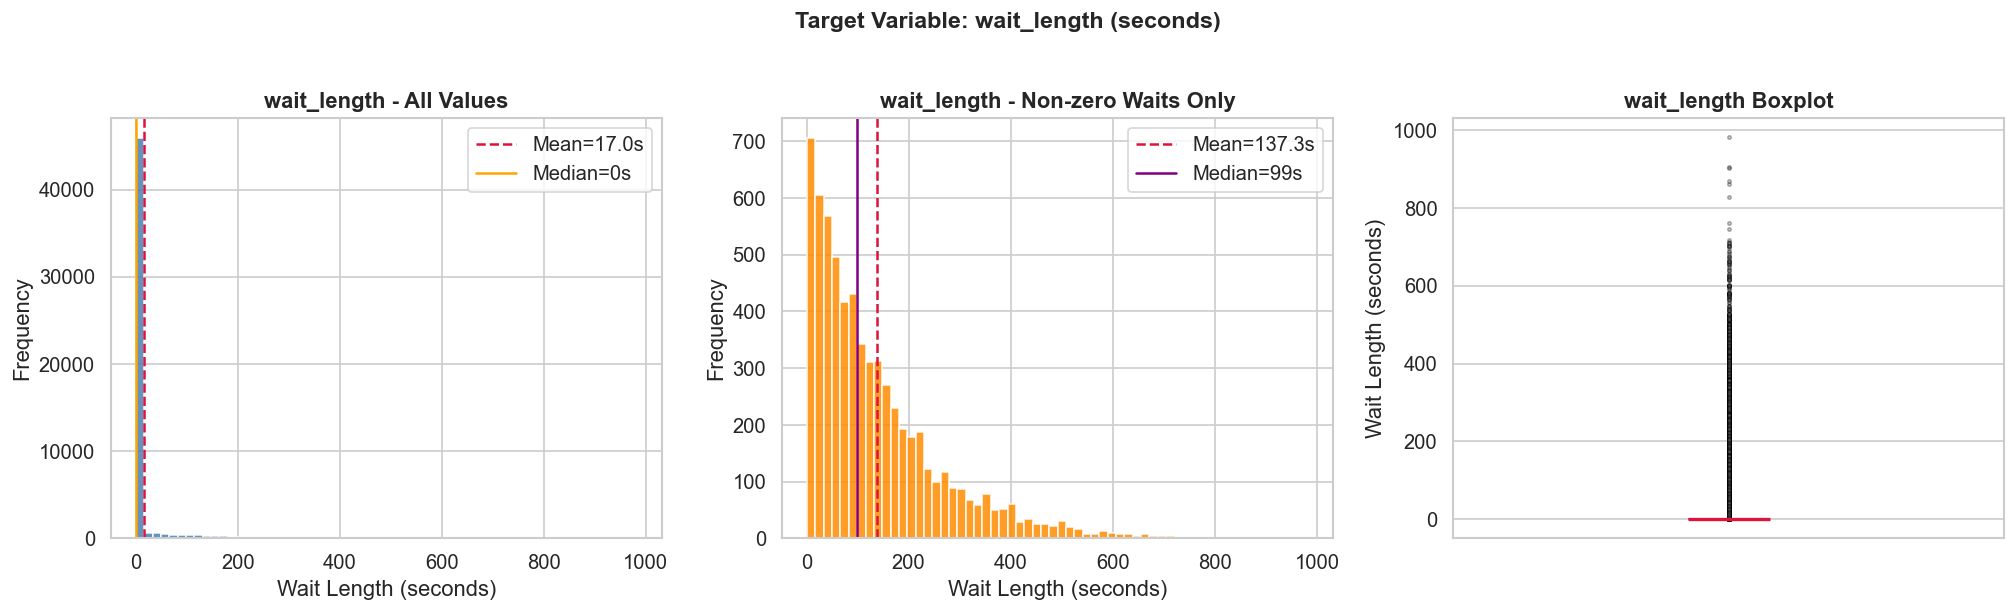

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Plot 1: All values
axes[0].hist(wl, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(wl.mean(),   color='crimson', linestyle='--', lw=1.5, label=f'Mean={wl.mean():.1f}s')
axes[0].axvline(wl.median(), color='orange',  linestyle='-',  lw=1.5, label=f'Median={wl.median():.0f}s')
axes[0].set_title('wait_length - All Values', fontweight='bold')
axes[0].set_xlabel('Wait Length (seconds)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Plot 2: Non-zero waits only
wl_nz = wl[wl > 0]
axes[1].hist(wl_nz, bins=60, color='darkorange', edgecolor='white', alpha=0.85)
axes[1].axvline(wl_nz.mean(),   color='crimson', linestyle='--', lw=1.5, label=f'Mean={wl_nz.mean():.1f}s')
axes[1].axvline(wl_nz.median(), color='purple',  linestyle='-',  lw=1.5, label=f'Median={wl_nz.median():.0f}s')
axes[1].set_title('wait_length - Non-zero Waits Only', fontweight='bold')
axes[1].set_xlabel('Wait Length (seconds)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

# Plot 3: Boxplot
axes[2].boxplot(wl, vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightcyan', color='steelblue'),
                medianprops=dict(color='crimson', linewidth=2),
                flierprops=dict(marker='o', markerfacecolor='gray', markersize=2, alpha=0.3))
axes[2].set_title('wait_length Boxplot', fontweight='bold')
axes[2].set_ylabel('Wait Length (seconds)')
axes[2].set_xticks([])

plt.suptitle('Target Variable: wait_length (seconds)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:**
- **87.6% of calls have zero wait** — the majority of callers are answered immediately.
- Among the 12.4% who do wait, the distribution is **heavily right-skewed** (skewness ≈ 5.26).
- The mean wait (17s) greatly exceeds the median (0s) due to the long-wait minority.
- The maximum recorded wait is 983 seconds (~16 minutes).

### Regression vs. Classification

Since `wait_length` is continuous, this is a **regression problem**. There is no class imbalance issue in the classification sense. Instead, the key challenges are:
- **Zero-inflation:** 87.6% zero values will bias a naive model toward predicting zero.
- **Right-skewed tail:** Log-transformation will be required before training.
- **Outliers:** Extreme values in the upper tail may destabilise training if not handled.

---

## 16. Feature Distributions

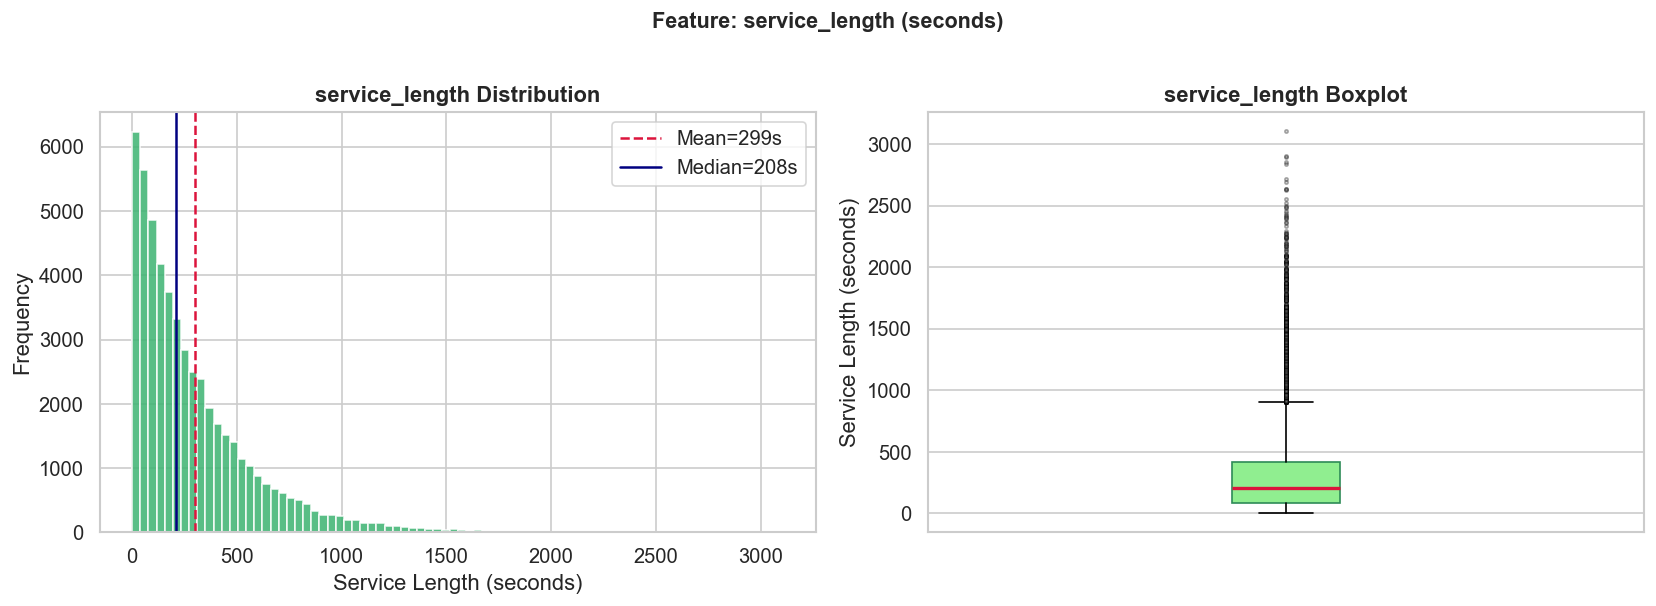

service_length -- Mean: 299.1s | Median: 208s | Skewness: 2.03


In [21]:
sl = df['service_length']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(sl, bins=80, color='mediumseagreen', edgecolor='white', alpha=0.85)
axes[0].axvline(sl.mean(),   color='crimson', linestyle='--', lw=1.5, label=f'Mean={sl.mean():.0f}s')
axes[0].axvline(sl.median(), color='navy',    linestyle='-',  lw=1.5, label=f'Median={sl.median():.0f}s')
axes[0].set_title('service_length Distribution', fontweight='bold')
axes[0].set_xlabel('Service Length (seconds)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].boxplot(sl, vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightgreen', color='seagreen'),
                medianprops=dict(color='crimson', linewidth=2),
                flierprops=dict(marker='o', markerfacecolor='gray', markersize=2, alpha=0.3))
axes[1].set_title('service_length Boxplot', fontweight='bold')
axes[1].set_ylabel('Service Length (seconds)')
axes[1].set_xticks([])

plt.suptitle('Feature: service_length (seconds)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_service_length.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'service_length -- Mean: {sl.mean():.1f}s | Median: {sl.median():.0f}s | Skewness: {sl.skew():.2f}')

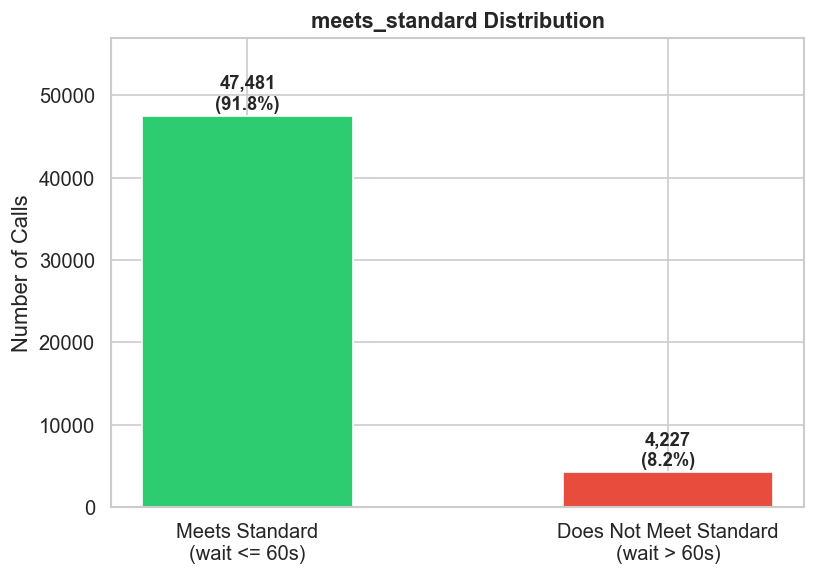

meets_standard
True    91.8252
False    8.1748
Name: proportion, dtype: float64


In [22]:
ms_counts = df['meets_standard'].value_counts()
ms_pct    = df['meets_standard'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(
    ['Meets Standard\n(wait <= 60s)', 'Does Not Meet Standard\n(wait > 60s)'],
    ms_counts.values, color=['#2ecc71', '#e74c3c'], edgecolor='white', width=0.5)

for bar, count, pct in zip(bars, ms_counts.values, ms_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
            f'{count:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('meets_standard Distribution', fontweight='bold', fontsize=13)
ax.set_ylabel('Number of Calls')
ax.set_ylim(0, ms_counts.max() * 1.2)
plt.tight_layout()
plt.savefig('fig_meets_standard.png', dpi=150, bbox_inches='tight')
plt.show()
print(ms_pct)

**Interpretation:**
- `service_length` is right-skewed (skewness ≈ 2.03), consistent with an exponential distribution (by simulation design).
- **91.8% of calls meet the standard** — answered within 60 seconds. Only 8.2% do not.
- If `meets_standard` were used as a classification target, the ~92/8 class imbalance would require special handling (oversampling, class weights, or threshold tuning).

---

## 17. Temporal Analysis

In [23]:
# Engineer temporal features
df['day_of_week']   = df['date'].dt.day_name()
df['day_of_week_n'] = df['date'].dt.dayofweek
df['month']         = df['date'].dt.month
df['week_of_year']  = df['date'].dt.isocalendar().week.astype(int)

print('Temporal features added.')
print(df[['call_id','date','hour_of_call','day_of_week','month']].head(3))

Temporal features added.
   call_id       date  hour_of_call day_of_week  month
0        1 2021-01-01             8      Friday      1
1        2 2021-01-01             8      Friday      1
2        3 2021-01-01             8      Friday      1


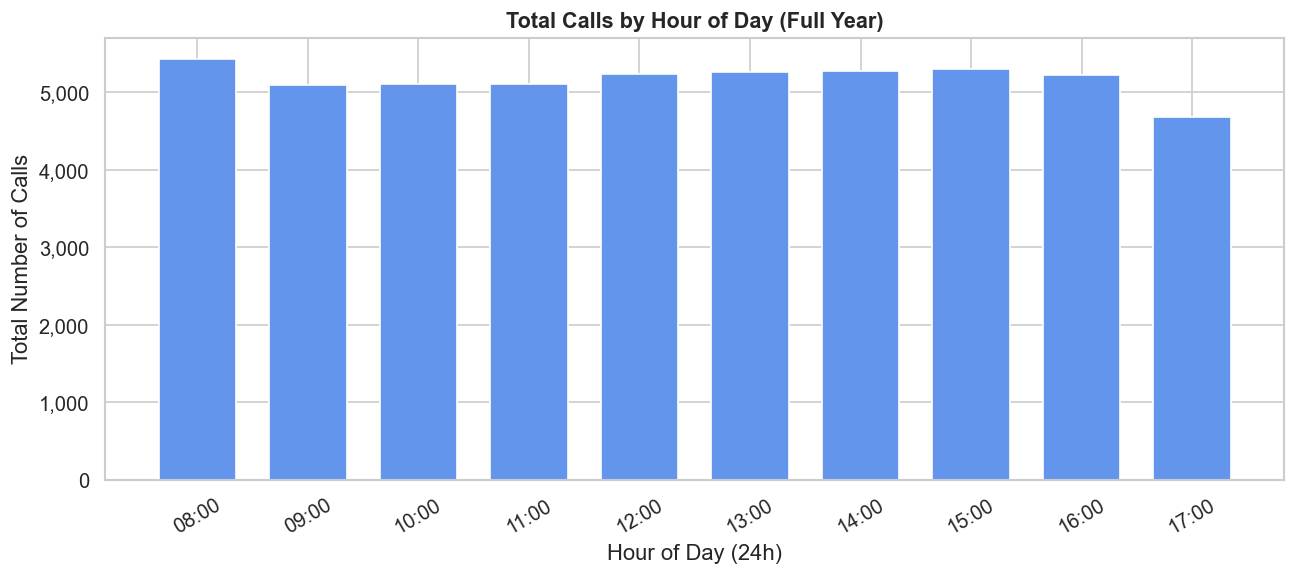

In [24]:
hourly_counts = df.groupby('hour_of_call').size().reset_index(name='call_count')

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(hourly_counts['hour_of_call'], hourly_counts['call_count'],
       color='cornflowerblue', edgecolor='white', width=0.7)
ax.set_title('Total Calls by Hour of Day (Full Year)', fontweight='bold', fontsize=13)
ax.set_xlabel('Hour of Day (24h)')
ax.set_ylabel('Total Number of Calls')
ax.set_xticks(hourly_counts['hour_of_call'])
ax.set_xticklabels([f'{h:02d}:00' for h in hourly_counts['hour_of_call']], rotation=30)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('fig_hourly_arrivals.png', dpi=150, bbox_inches='tight')
plt.show()

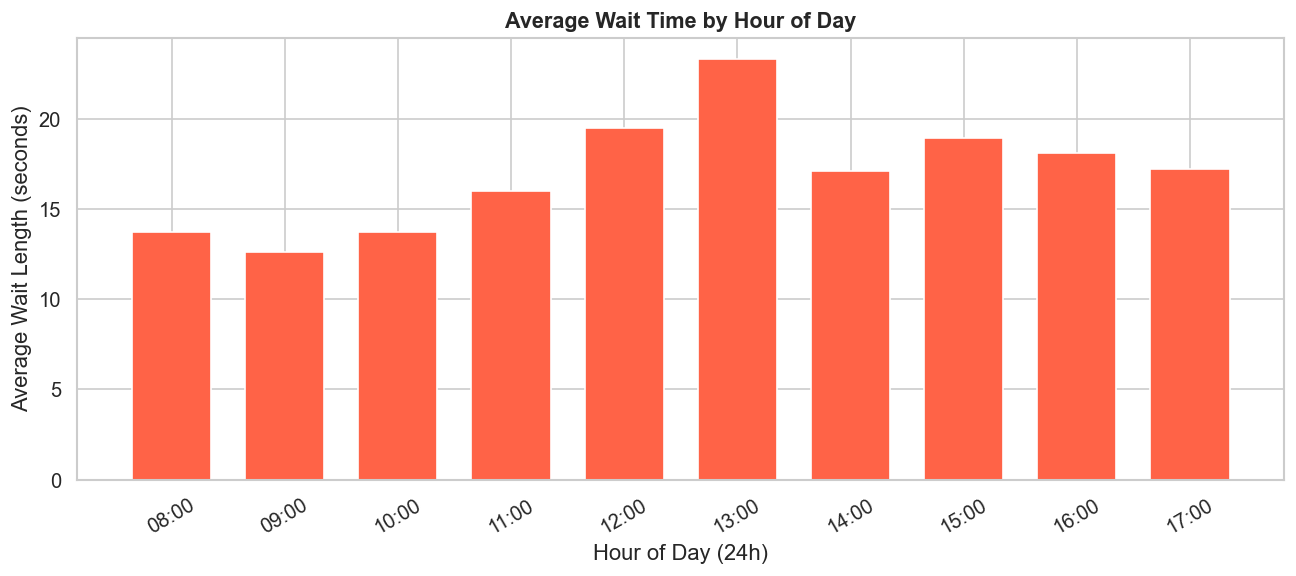

In [25]:
hourly_wait = df.groupby('hour_of_call')['wait_length'].mean().reset_index()

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(hourly_wait['hour_of_call'], hourly_wait['wait_length'],
       color='tomato', edgecolor='white', width=0.7)
ax.set_title('Average Wait Time by Hour of Day', fontweight='bold', fontsize=13)
ax.set_xlabel('Hour of Day (24h)')
ax.set_ylabel('Average Wait Length (seconds)')
ax.set_xticks(hourly_wait['hour_of_call'])
ax.set_xticklabels([f'{h:02d}:00' for h in hourly_wait['hour_of_call']], rotation=30)
plt.tight_layout()
plt.savefig('fig_hourly_wait.png', dpi=150, bbox_inches='tight')
plt.show()

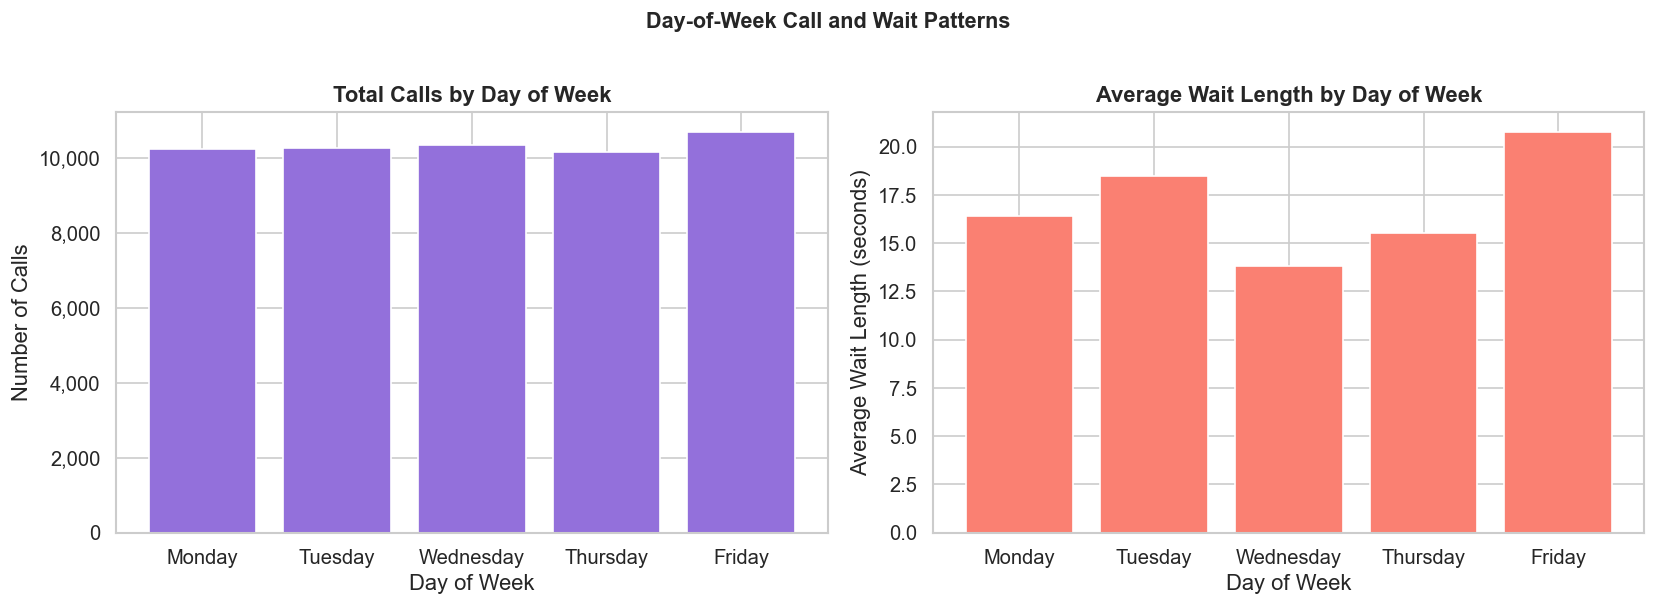

In [26]:
day_order  = ['Monday','Tuesday','Wednesday','Thursday','Friday']
dow_counts = df.groupby('day_of_week').size().reindex(day_order).reset_index(name='call_count')
dow_wait   = df.groupby('day_of_week')['wait_length'].mean().reindex(day_order).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(dow_counts['day_of_week'], dow_counts['call_count'],
            color='mediumpurple', edgecolor='white')
axes[0].set_title('Total Calls by Day of Week', fontweight='bold')
axes[0].set_xlabel('Day of Week')
axes[0].set_ylabel('Number of Calls')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

axes[1].bar(dow_wait['day_of_week'], dow_wait['wait_length'],
            color='salmon', edgecolor='white')
axes[1].set_title('Average Wait Length by Day of Week', fontweight='bold')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Average Wait Length (seconds)')

plt.suptitle('Day-of-Week Call and Wait Patterns', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_dow_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

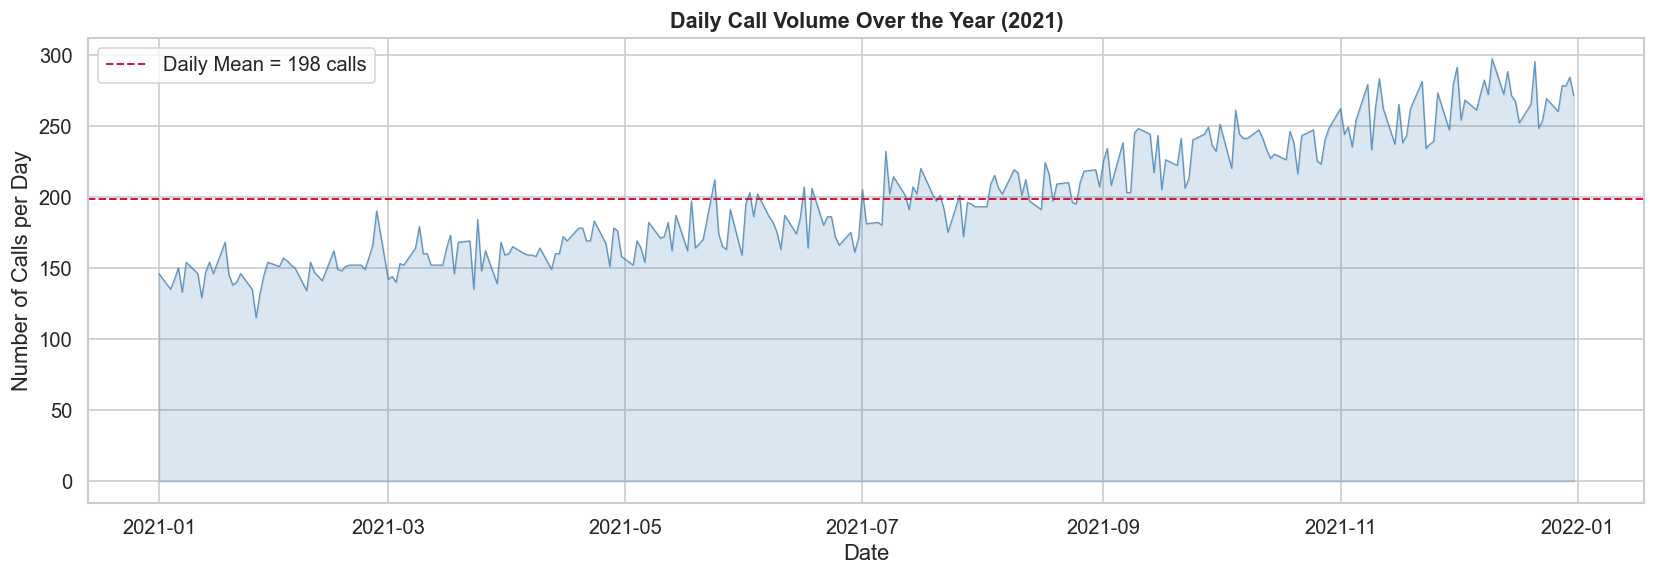

Daily call volume -- Mean: 198.1 | Min: 115 | Max: 297


In [27]:
calls_per_day = df.groupby('date').size().reset_index(name='call_count')

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(calls_per_day['date'], calls_per_day['call_count'],
        color='steelblue', linewidth=0.8, alpha=0.8)
ax.fill_between(calls_per_day['date'], calls_per_day['call_count'],
                alpha=0.2, color='steelblue')
ax.axhline(calls_per_day['call_count'].mean(), color='crimson', linestyle='--', lw=1.2,
           label=f'Daily Mean = {calls_per_day["call_count"].mean():.0f} calls')
ax.set_title('Daily Call Volume Over the Year (2021)', fontweight='bold', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Number of Calls per Day')
ax.legend()
plt.tight_layout()
plt.savefig('fig_daily_volume.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Daily call volume -- Mean: {calls_per_day["call_count"].mean():.1f} | '
      f'Min: {calls_per_day["call_count"].min()} | Max: {calls_per_day["call_count"].max()}')

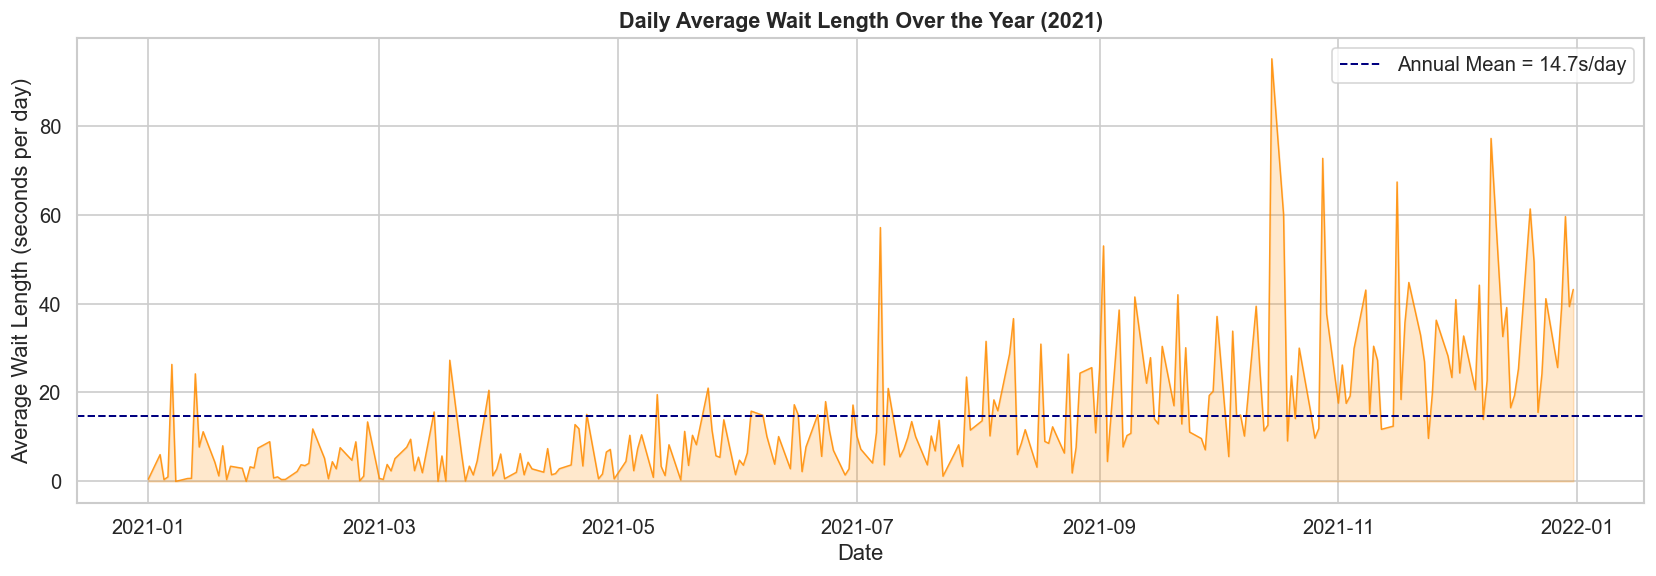

In [28]:
daily_avg_wait = df.groupby('date')['wait_length'].mean().reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily_avg_wait['date'], daily_avg_wait['wait_length'],
        color='darkorange', linewidth=0.9, alpha=0.85)
ax.fill_between(daily_avg_wait['date'], daily_avg_wait['wait_length'],
                alpha=0.2, color='darkorange')
ax.axhline(daily_avg_wait['wait_length'].mean(), color='navy', linestyle='--', lw=1.2,
           label=f'Annual Mean = {daily_avg_wait["wait_length"].mean():.1f}s/day')
ax.set_title('Daily Average Wait Length Over the Year (2021)', fontweight='bold', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Average Wait Length (seconds per day)')
ax.legend()
plt.tight_layout()
plt.savefig('fig_daily_wait.png', dpi=150, bbox_inches='tight')
plt.show()

**Temporal Analysis Interpretation:**
- Call volume is broadly **uniform across all hours** (8am–5pm), with a slight dip in the final hour.
- Average wait time varies by hour, reflecting periods when queue buildup is most likely.
- **Friday has the highest total call volume** (10,695 calls); Thursday has the fewest (10,162).
- Daily call volume varies between 115 and 297, showing day-to-day variability the LSTM must learn.

---

## 18. Important Feature Relationships

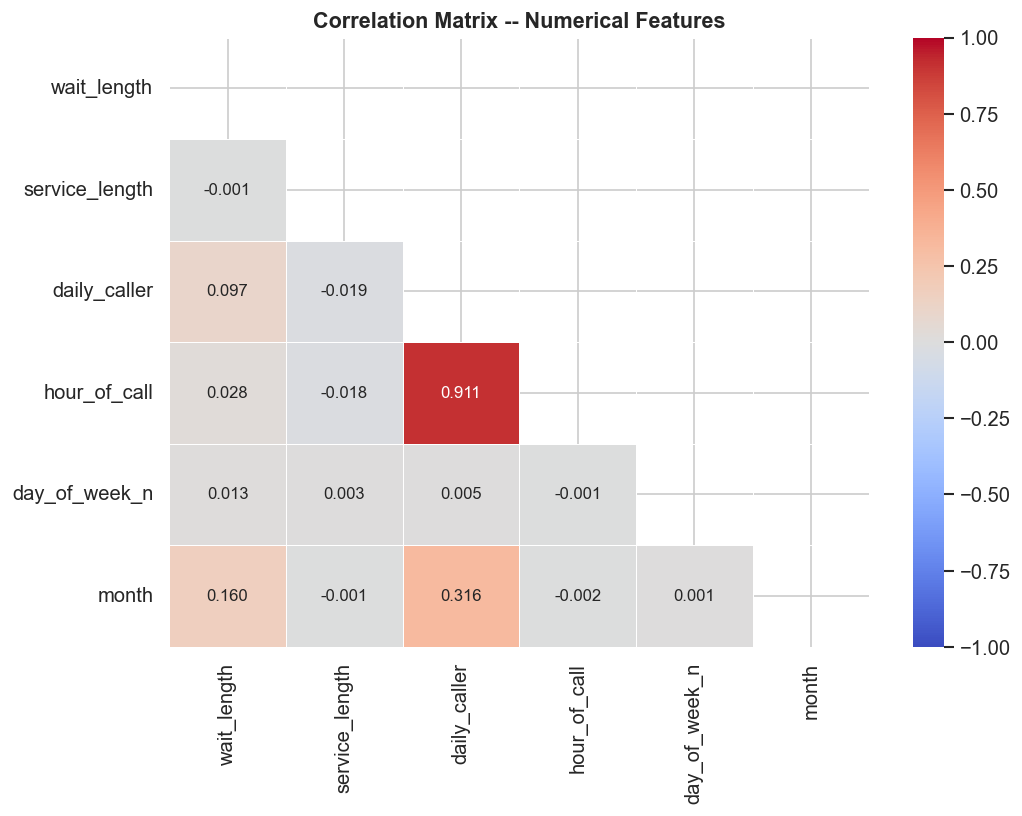

In [29]:
numeric_df  = df[['wait_length','service_length','daily_caller','hour_of_call','day_of_week_n','month']]
corr_matrix = numeric_df.corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax, mask=mask,
            annot_kws={'size': 10})
ax.set_title('Correlation Matrix -- Numerical Features', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('fig_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

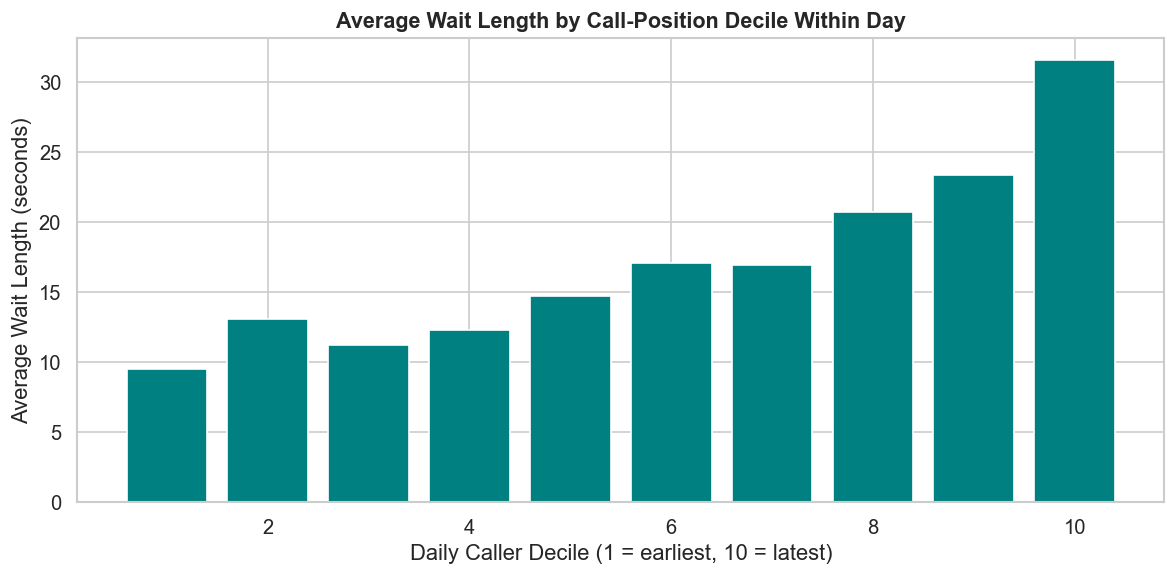

In [30]:
# wait_length vs call position decile within the day
df['caller_decile'] = pd.qcut(df['daily_caller'], q=10, labels=False, duplicates='drop') + 1
wait_by_decile = df.groupby('caller_decile')['wait_length'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(wait_by_decile['caller_decile'], wait_by_decile['wait_length'],
       color='teal', edgecolor='white')
ax.set_title('Average Wait Length by Call-Position Decile Within Day', fontweight='bold', fontsize=13)
ax.set_xlabel('Daily Caller Decile (1 = earliest, 10 = latest)')
ax.set_ylabel('Average Wait Length (seconds)')
plt.tight_layout()
plt.savefig('fig_wait_by_position.png', dpi=150, bbox_inches='tight')
plt.show()

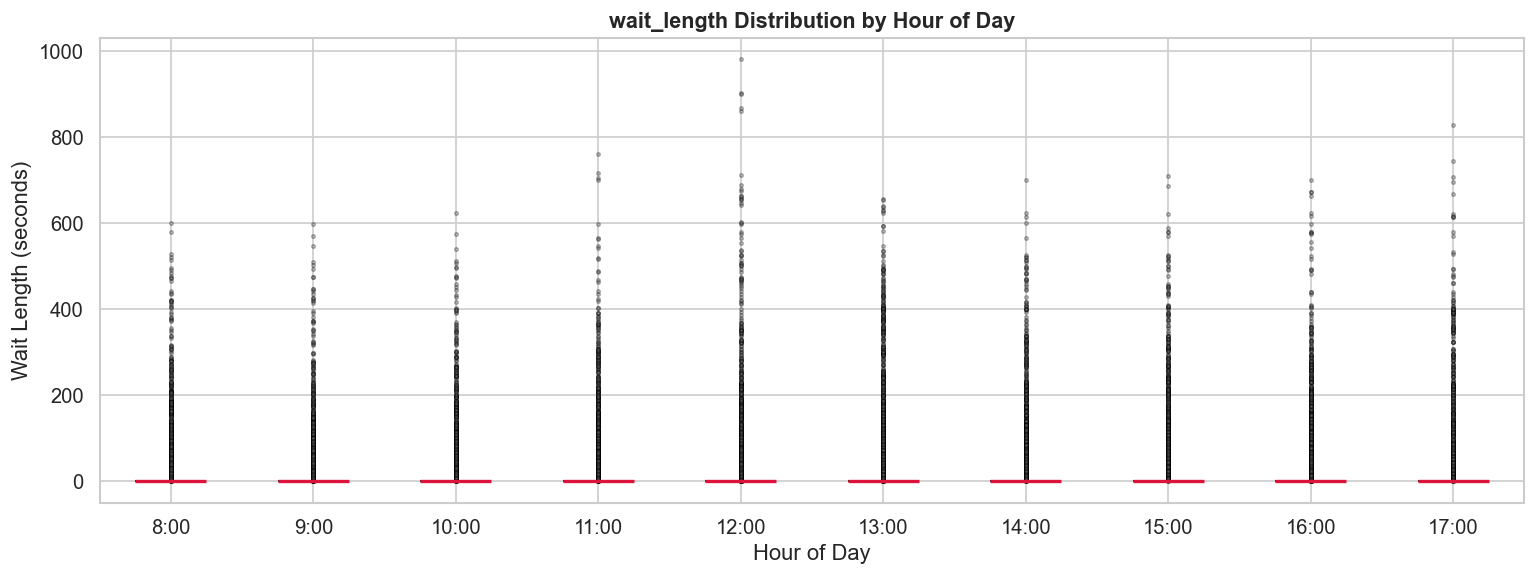

In [31]:
# Boxplot: wait_length by hour
fig, ax = plt.subplots(figsize=(13, 5))
hours        = sorted(df['hour_of_call'].unique())
data_by_hour = [df.loc[df['hour_of_call'] == h, 'wait_length'].values for h in hours]

bp = ax.boxplot(data_by_hour, patch_artist=True, labels=[f'{h}:00' for h in hours],
                flierprops=dict(marker='o', markersize=2, alpha=0.3, markerfacecolor='gray'),
                medianprops=dict(color='crimson', linewidth=2))

means_h = [np.mean(d) for d in data_by_hour]
norm_h  = [(m - min(means_h)) / (max(means_h) - min(means_h) + 1e-9) for m in means_h]
cmap_use = cm.get_cmap('YlOrRd')
for patch, nm in zip(bp['boxes'], norm_h):
    patch.set_facecolor(cmap_use(nm))

ax.set_title('wait_length Distribution by Hour of Day', fontweight='bold', fontsize=13)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Wait Length (seconds)')
plt.tight_layout()
plt.savefig('fig_wait_by_hour_box.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:**
- Pairwise linear correlations between `wait_length`, `service_length`, and `daily_caller` are low. Individual call metrics do not directly predict the next caller's wait in a pairwise sense.
- `daily_caller` (r ≈ 0.097 with `wait_length`) shows that calls later in the day tend to wait slightly longer, consistent with queue accumulation.
- The key relationship is **temporal and sequential**: cumulative service burden on agents, not any single call's metrics, drives queue behaviour.

---

## 19. Three Key Findings

These three findings are specifically chosen because they will directly shape the future RNN/LSTM model architecture and training strategy.

---

### Finding 1: wait_length is Zero-Inflated and Extremely Right-Skewed

**Evidence:**

Percentage of zero-wait calls : 87.6%
Raw wait_length skewness      : 5.260
log(1+wait_length) skewness   : 2.550


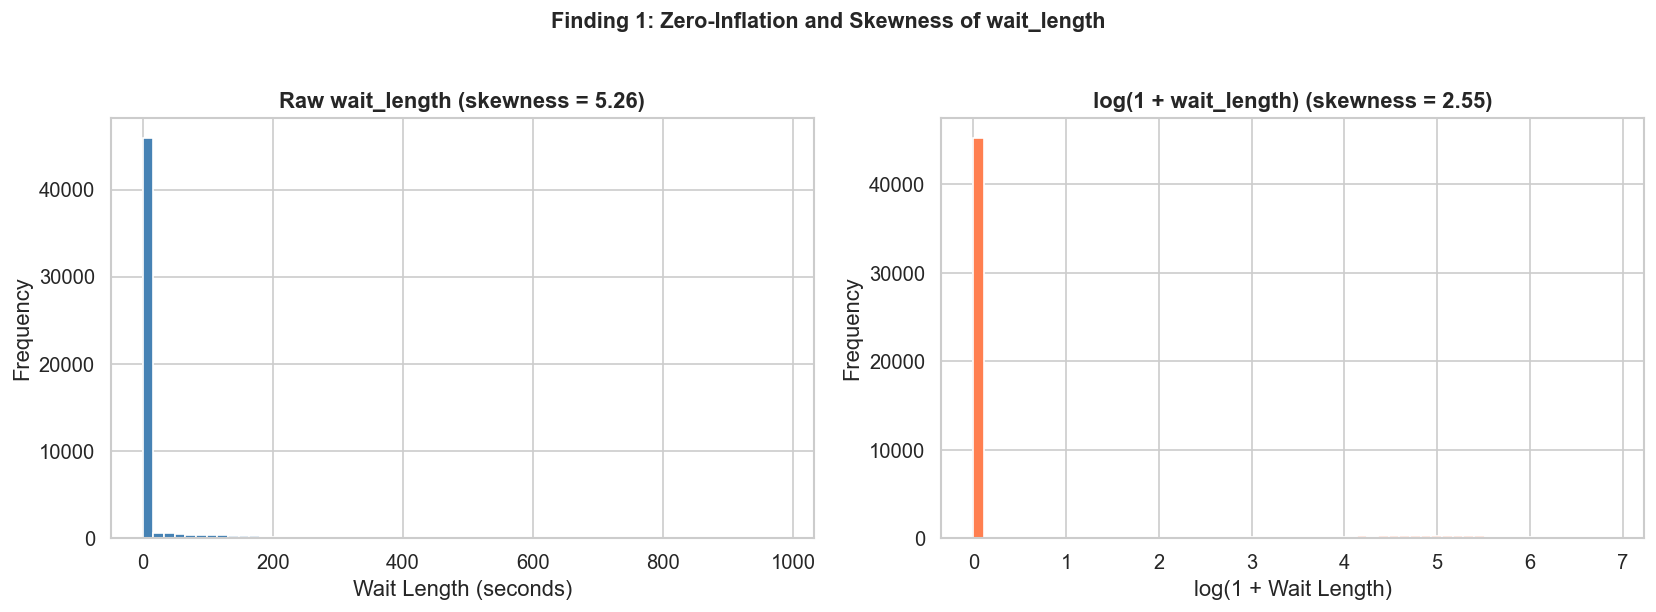

In [32]:
pct_zero  = (df['wait_length'] == 0).mean() * 100
skew_raw  = df['wait_length'].skew()
skew_log  = np.log1p(df['wait_length']).skew()

print(f'Percentage of zero-wait calls : {pct_zero:.1f}%')
print(f'Raw wait_length skewness      : {skew_raw:.3f}')
print(f'log(1+wait_length) skewness   : {skew_log:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['wait_length'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title(f'Raw wait_length (skewness = {skew_raw:.2f})', fontweight='bold')
axes[0].set_xlabel('Wait Length (seconds)')
axes[0].set_ylabel('Frequency')

axes[1].hist(np.log1p(df['wait_length']), bins=60, color='coral', edgecolor='white')
axes[1].set_title(f'log(1 + wait_length) (skewness = {skew_log:.2f})', fontweight='bold')
axes[1].set_xlabel('log(1 + Wait Length)')
axes[1].set_ylabel('Frequency')

plt.suptitle('Finding 1: Zero-Inflation and Skewness of wait_length', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_finding1.png', dpi=150, bbox_inches='tight')
plt.show()

**What this means:**  
87.6% of records have `wait_length = 0`. Among the minority who wait, the distribution is heavily right-skewed (skewness ≈ 5.26). A log(1+x) transformation reduces this substantially.

**Impact on future RNN/LSTM model:**
1. **Target transformation required:** Train on `log(1 + wait_length)` and inverse-transform predictions.
2. **Consider a two-stage model:** Stage 1 — binary classifier (will any wait occur?); Stage 2 — regressor for the wait magnitude.
3. **Loss function:** MAE or Huber loss will be more robust than MSE for this heavy-tailed distribution.

---

### Finding 2: Hour-of-Day Strongly Influences Wait Probability

**Evidence:**

Hourly call statistics:
 hour_of_call  total_calls  avg_wait  pct_waited
            8         5434   13.7468     10.9864
            9         5099   12.6225     11.9631
           10         5102   13.7087     11.7405
           11         5103   16.0004     11.2875
           12         5236   19.4992     12.1849
           13         5258   23.3165     15.0247
           14         5270   17.1102     12.7894
           15         5305   18.9361     13.8360
           16         5225   18.0725     13.3397
           17         4676   17.2019     10.7357


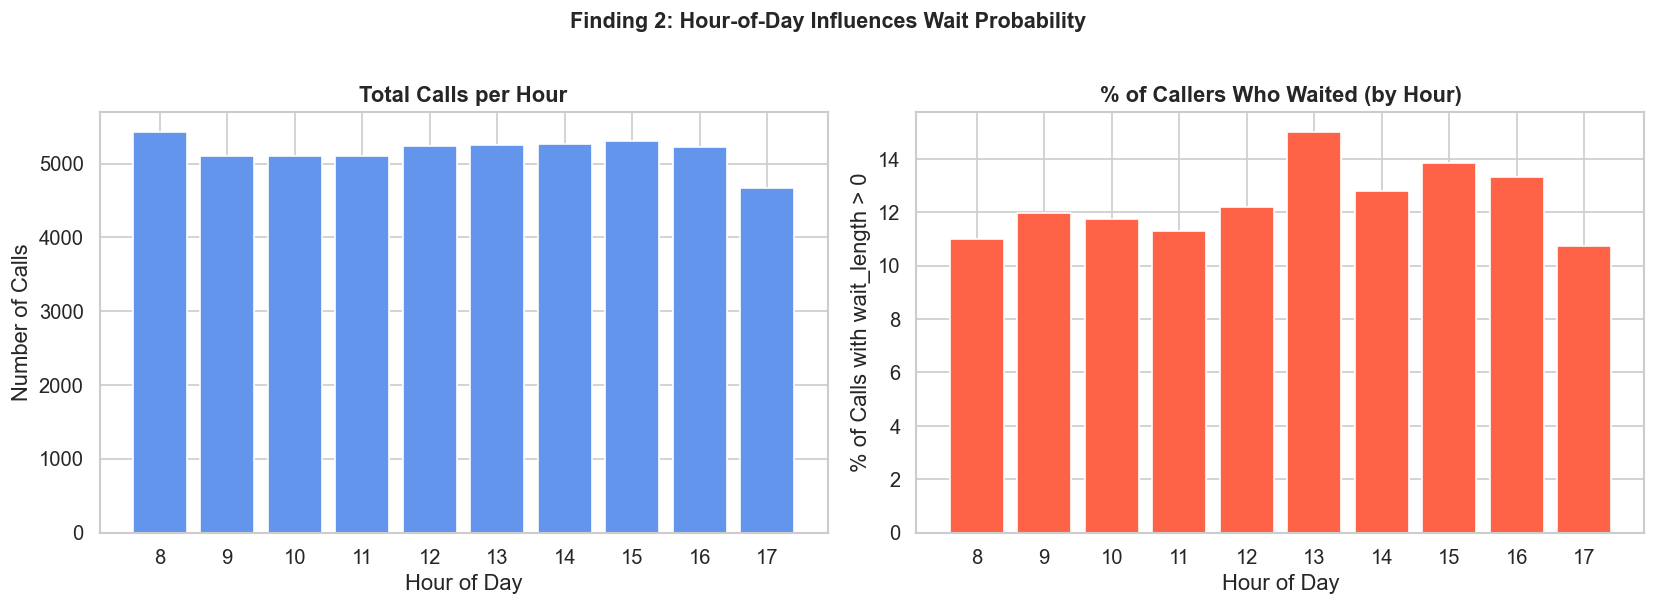

In [33]:
hourly_stats = df.groupby('hour_of_call').agg(
    total_calls = ('wait_length', 'count'),
    avg_wait    = ('wait_length', 'mean'),
    pct_waited  = ('wait_length', lambda x: (x > 0).mean() * 100)
).reset_index()

print('Hourly call statistics:')
print(hourly_stats.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(hourly_stats['hour_of_call'], hourly_stats['total_calls'],
            color='cornflowerblue', edgecolor='white')
axes[0].set_title('Total Calls per Hour', fontweight='bold')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Number of Calls')
axes[0].set_xticks(hourly_stats['hour_of_call'])

axes[1].bar(hourly_stats['hour_of_call'], hourly_stats['pct_waited'],
            color='tomato', edgecolor='white')
axes[1].set_title('% of Callers Who Waited (by Hour)', fontweight='bold')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('% of Calls with wait_length > 0')
axes[1].set_xticks(hourly_stats['hour_of_call'])

plt.suptitle('Finding 2: Hour-of-Day Influences Wait Probability', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_finding2.png', dpi=150, bbox_inches='tight')
plt.show()

**What this means:**  
The proportion of callers who experience a non-zero wait varies meaningfully by hour. Mid-morning and mid-afternoon periods see the highest wait rates, reflecting periods when queue buildup is most likely.

**Impact on future RNN/LSTM model:**
1. **Include hour-of-call as an input feature** — encode cyclically using sin/cos to preserve circular time relationships.
2. **Include day-of-week** as an input feature (Friday is consistently the busiest day).
3. These features are available before a call is answered, making them valid real-time prediction inputs.

---

### Finding 3: The Dataset is Chronologically Ordered — Random Splitting Causes Data Leakage

**Evidence:**

Is date monotonically increasing with call_id? True


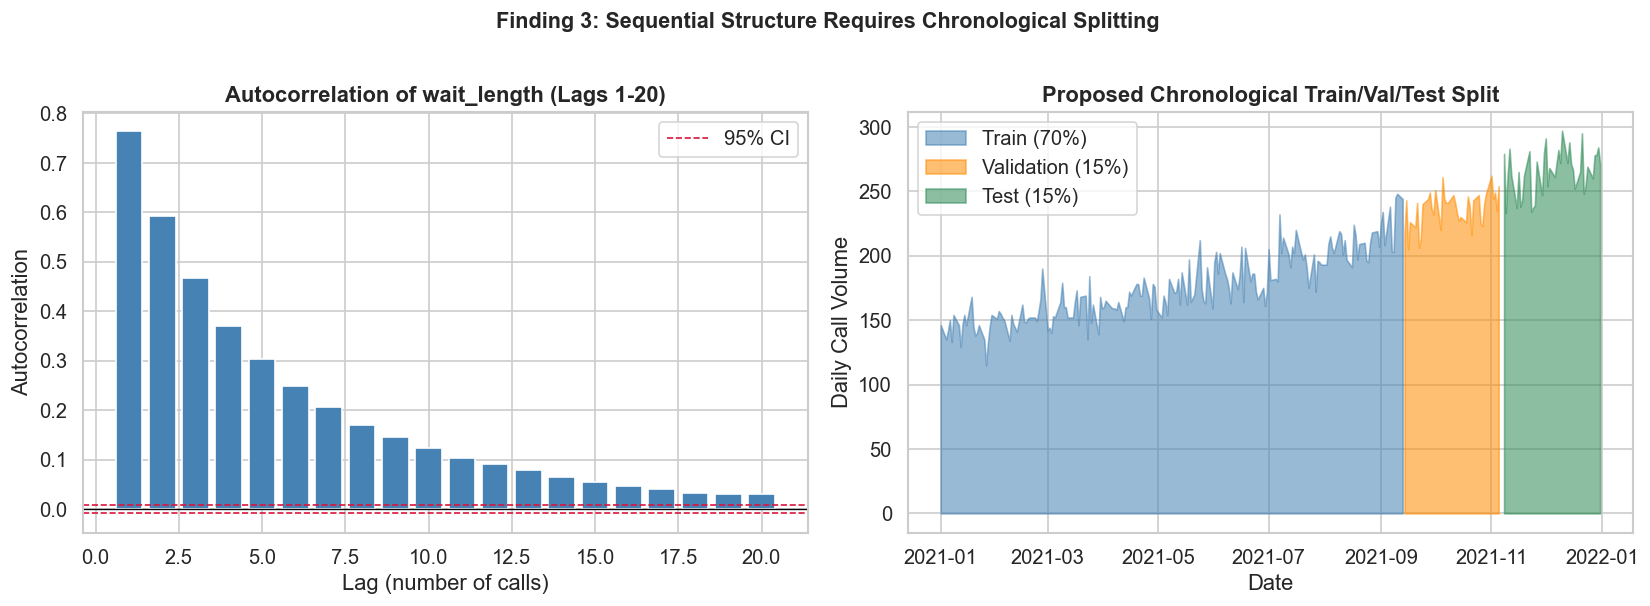

Autocorrelation at lag 1 : 0.7649
Autocorrelation at lag 5 : 0.3025
Autocorrelation at lag 10: 0.1243


In [34]:
# Verify monotonic ordering
df_sorted    = df.sort_values('call_id')
is_monotonic = df_sorted['date'].is_monotonic_increasing
print(f'Is date monotonically increasing with call_id? {is_monotonic}')

# Autocorrelation of wait_length sequence
wait_series = df_sorted['wait_length'].values
n_lags      = 20
autocorrs   = [pd.Series(wait_series).autocorr(lag=lag) for lag in range(1, n_lags + 1)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Autocorrelation bar chart
axes[0].bar(range(1, n_lags + 1), autocorrs, color='steelblue', edgecolor='white')
axes[0].axhline(0, color='black', linewidth=0.8)
ci = 1.96 / np.sqrt(len(wait_series))
axes[0].axhline( ci, color='crimson', linestyle='--', lw=1, label='95% CI')
axes[0].axhline(-ci, color='crimson', linestyle='--', lw=1)
axes[0].set_title('Autocorrelation of wait_length (Lags 1-20)', fontweight='bold')
axes[0].set_xlabel('Lag (number of calls)')
axes[0].set_ylabel('Autocorrelation')
axes[0].legend()

# Chronological split visualisation
calls_per_day  = df.groupby('date').size().reset_index(name='call_count')
all_dates      = sorted(calls_per_day['date'].values)
n_days_total   = len(all_dates)
train_end_d    = all_dates[int(n_days_total * 0.70) - 1]
val_end_d      = all_dates[int(n_days_total * 0.85) - 1]

axes[1].fill_between(calls_per_day['date'], calls_per_day['call_count'],
                     where=(calls_per_day['date'] <= train_end_d),
                     alpha=0.55, color='steelblue', label='Train (70%)')
axes[1].fill_between(calls_per_day['date'], calls_per_day['call_count'],
                     where=((calls_per_day['date'] > train_end_d) &
                            (calls_per_day['date'] <= val_end_d)),
                     alpha=0.55, color='darkorange', label='Validation (15%)')
axes[1].fill_between(calls_per_day['date'], calls_per_day['call_count'],
                     where=(calls_per_day['date'] > val_end_d),
                     alpha=0.55, color='seagreen', label='Test (15%)')
axes[1].set_title('Proposed Chronological Train/Val/Test Split', fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Daily Call Volume')
axes[1].legend()

plt.suptitle('Finding 3: Sequential Structure Requires Chronological Splitting',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_finding3.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Autocorrelation at lag 1 : {autocorrs[0]:.4f}')
print(f'Autocorrelation at lag 5 : {autocorrs[4]:.4f}')
print(f'Autocorrelation at lag 10: {autocorrs[9]:.4f}')

**What this means:**  
The dataset is strictly ordered chronologically by `call_id`. Each call's wait time depends on prior calls and current queue state. Autocorrelation at short lags is statistically significant, confirming that consecutive calls are not independent.

**Impact on future RNN/LSTM model:**
1. **Never use random train_test_split.** Random shuffling allows the model to train on future data — this is data leakage and produces inflated metrics.
2. **Use strictly chronological splitting:** 70% for training, 15% for validation, 15% for testing.
3. **LSTM sequence construction** must happen after the split so no sequence bridges a partition boundary.
4. The autocorrelation pattern supports using a **look-back window of 10–30 consecutive calls** as the LSTM input sequence.

---

## 20. Train / Validation / Test Split Strategy

In [35]:
df_sorted_final = df.sort_values('call_id').reset_index(drop=True)

unique_dates_sorted = sorted(df_sorted_final['date'].unique())
n_days_total        = len(unique_dates_sorted)

train_cutoff = unique_dates_sorted[int(n_days_total * 0.70) - 1]
val_cutoff   = unique_dates_sorted[int(n_days_total * 0.85) - 1]

df_train = df_sorted_final[df_sorted_final['date'] <= train_cutoff]
df_val   = df_sorted_final[(df_sorted_final['date'] > train_cutoff) &
                            (df_sorted_final['date'] <= val_cutoff)]
df_test  = df_sorted_final[df_sorted_final['date'] > val_cutoff]

print('=== Chronological Train / Validation / Test Split ===')
print(f'Total operating days: {n_days_total}')
print()
print(f'TRAIN:       {len(df_train):>6,} rows | '
      f'{pd.Timestamp(df_train["date"].min()).date()} to '
      f'{pd.Timestamp(df_train["date"].max()).date()} | '
      f'{len(df_train)/len(df_sorted_final)*100:.1f}%')
print(f'VALIDATION:  {len(df_val):>6,} rows | '
      f'{pd.Timestamp(df_val["date"].min()).date()} to '
      f'{pd.Timestamp(df_val["date"].max()).date()} | '
      f'{len(df_val)/len(df_sorted_final)*100:.1f}%')
print(f'TEST:        {len(df_test):>6,} rows | '
      f'{pd.Timestamp(df_test["date"].min()).date()} to '
      f'{pd.Timestamp(df_test["date"].max()).date()} | '
      f'{len(df_test)/len(df_sorted_final)*100:.1f}%')

=== Chronological Train / Validation / Test Split ===
Total operating days: 261

TRAIN:       31,898 rows | 2021-01-01 to 2021-09-13 | 61.7%
VALIDATION:   9,206 rows | 2021-09-14 to 2021-11-05 | 17.8%
TEST:        10,604 rows | 2021-11-08 to 2021-12-31 | 20.5%


### Why This Split is Appropriate

| Factor | Explanation |
|---|---|
| **Temporal ordering** | Dataset is ordered chronologically; each call depends on prior queue state |
| **No random shuffling** | Random splits allow future data to appear in training — data leakage |
| **70/15/15 ratio** | Sufficient training volume (~36,000 calls) while maintaining meaningful evaluation periods |
| **Day-level boundary** | Splitting at day boundaries prevents mid-day sequence contamination |
| **Sequence construction timing** | LSTM look-back windows must be built within each partition separately |

### How This Split Will Be Used in RNN/LSTM Training

1. **Training set:** Used to fit model weights via Backpropagation Through Time (BPTT).
2. **Validation set:** Used for hyperparameter tuning and early stopping.
3. **Test set:** Held completely unseen until final evaluation — reports true generalisation performance.

---

## 21. Implications for Future RNN/LSTM Design

| Design Decision | Rationale from EDA |
|---|---|
| **Target: `wait_length`** | Continuous, directly meaningful metric for queue recommendations |
| **Target transformation: log(1 + wait_length)** | Zero-inflated, right-skewed distribution requires normalisation |
| **Input features** | `hour_of_call` (cyclically encoded), `day_of_week`, `daily_caller`, rolling window of recent wait/service times |
| **Look-back window** | Significant autocorrelation at short lags supports a window of 10–30 consecutive calls |
| **Train/Val/Test split** | Strictly chronological (70/15/15) — no random shuffling |
| **Loss function** | MAE or Huber loss preferred over MSE given heavy-tailed distribution |
| **Architecture** | Stacked LSTM with dropout; start with 1–2 layers, tune depth on validation set |
| **Zero-wait handling** | Consider binary gating or two-stage model |
| **Service length as feature** | Rolling average of recent `service_length` captures agent busyness |
| **Outlier handling** | Cap extreme `service_length` values (above 99th percentile) before training |

---

## 22. EDA Conclusion

This exploratory data analysis examined the **Call Centre Queue Simulation** dataset containing **51,708 call records** spanning the full year 2021 (261 working days). The dataset is clean — no missing values, no duplicate rows — as expected for data generated by the `simmer` Discrete-Event Simulation package.

**Key conclusions:**

1. The **primary target variable is `wait_length`** (continuous seconds); this is a regression problem.
2. `wait_length` is **zero-inflated and heavily right-skewed** (skewness ≈ 5.26), requiring target transformation and careful loss function selection.
3. **Hourly and daily temporal patterns** in both volume and waiting time are clearly present, making time-of-day and day-of-week important LSTM input features.
4. The **strictly chronological dataset structure** mandates a time-based train/validation/test split to prevent data leakage.
5. Being **simulated data** limits direct real-world applicability, but the patterns demonstrated are representative and provide a solid basis for RNN/LSTM model design.

The dataset is well-suited for LSTM-based sequence modelling. The recommended next step (Week 3) is feature engineering — specifically, constructing rolling window features from consecutive call records to form LSTM input sequences.

---
**End of Week 2 EDA Notebook**